In [1]:
from InterOptimus.itworker import InterfaceWorker
from pymatgen.core.structure import Structure
from mp_api.client import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

/opt/anaconda3/envs/3.12/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


# Define InterfaceWorker

In [2]:
film_conv = Structure.from_file('film.cif')
substrate_conv = Structure.from_file('substrate.cif')
iw = InterfaceWorker(film_conv, substrate_conv)

/Users/jason/Downloads/pymatgen-master/src/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 12 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


# lattice matching

In [3]:
iw.lattice_matching(max_area = 30, max_length_tol = 0.03, max_angle_tol = 0.03,
                    film_max_miller = 1, substrate_max_miller = 1, film_millers = None, substrate_millers = None)
#Note max millers are in primitive cell, should be different from the indices in the polar projection below which are in conventional cell
#If you specify miller indices yourself, just ignore film_max_miller and substrate_max_miller

5


checking matching identity:   0%|          | 0/5 [00:00<?, ?it/s]

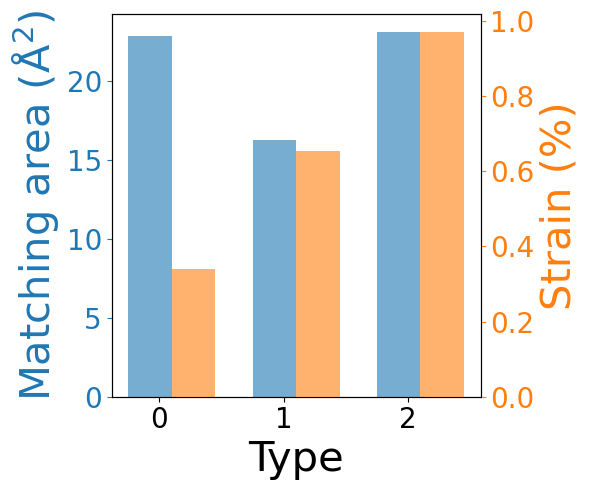

In [4]:
#Visualize matching information
iw.ems.plot_unique_matches()

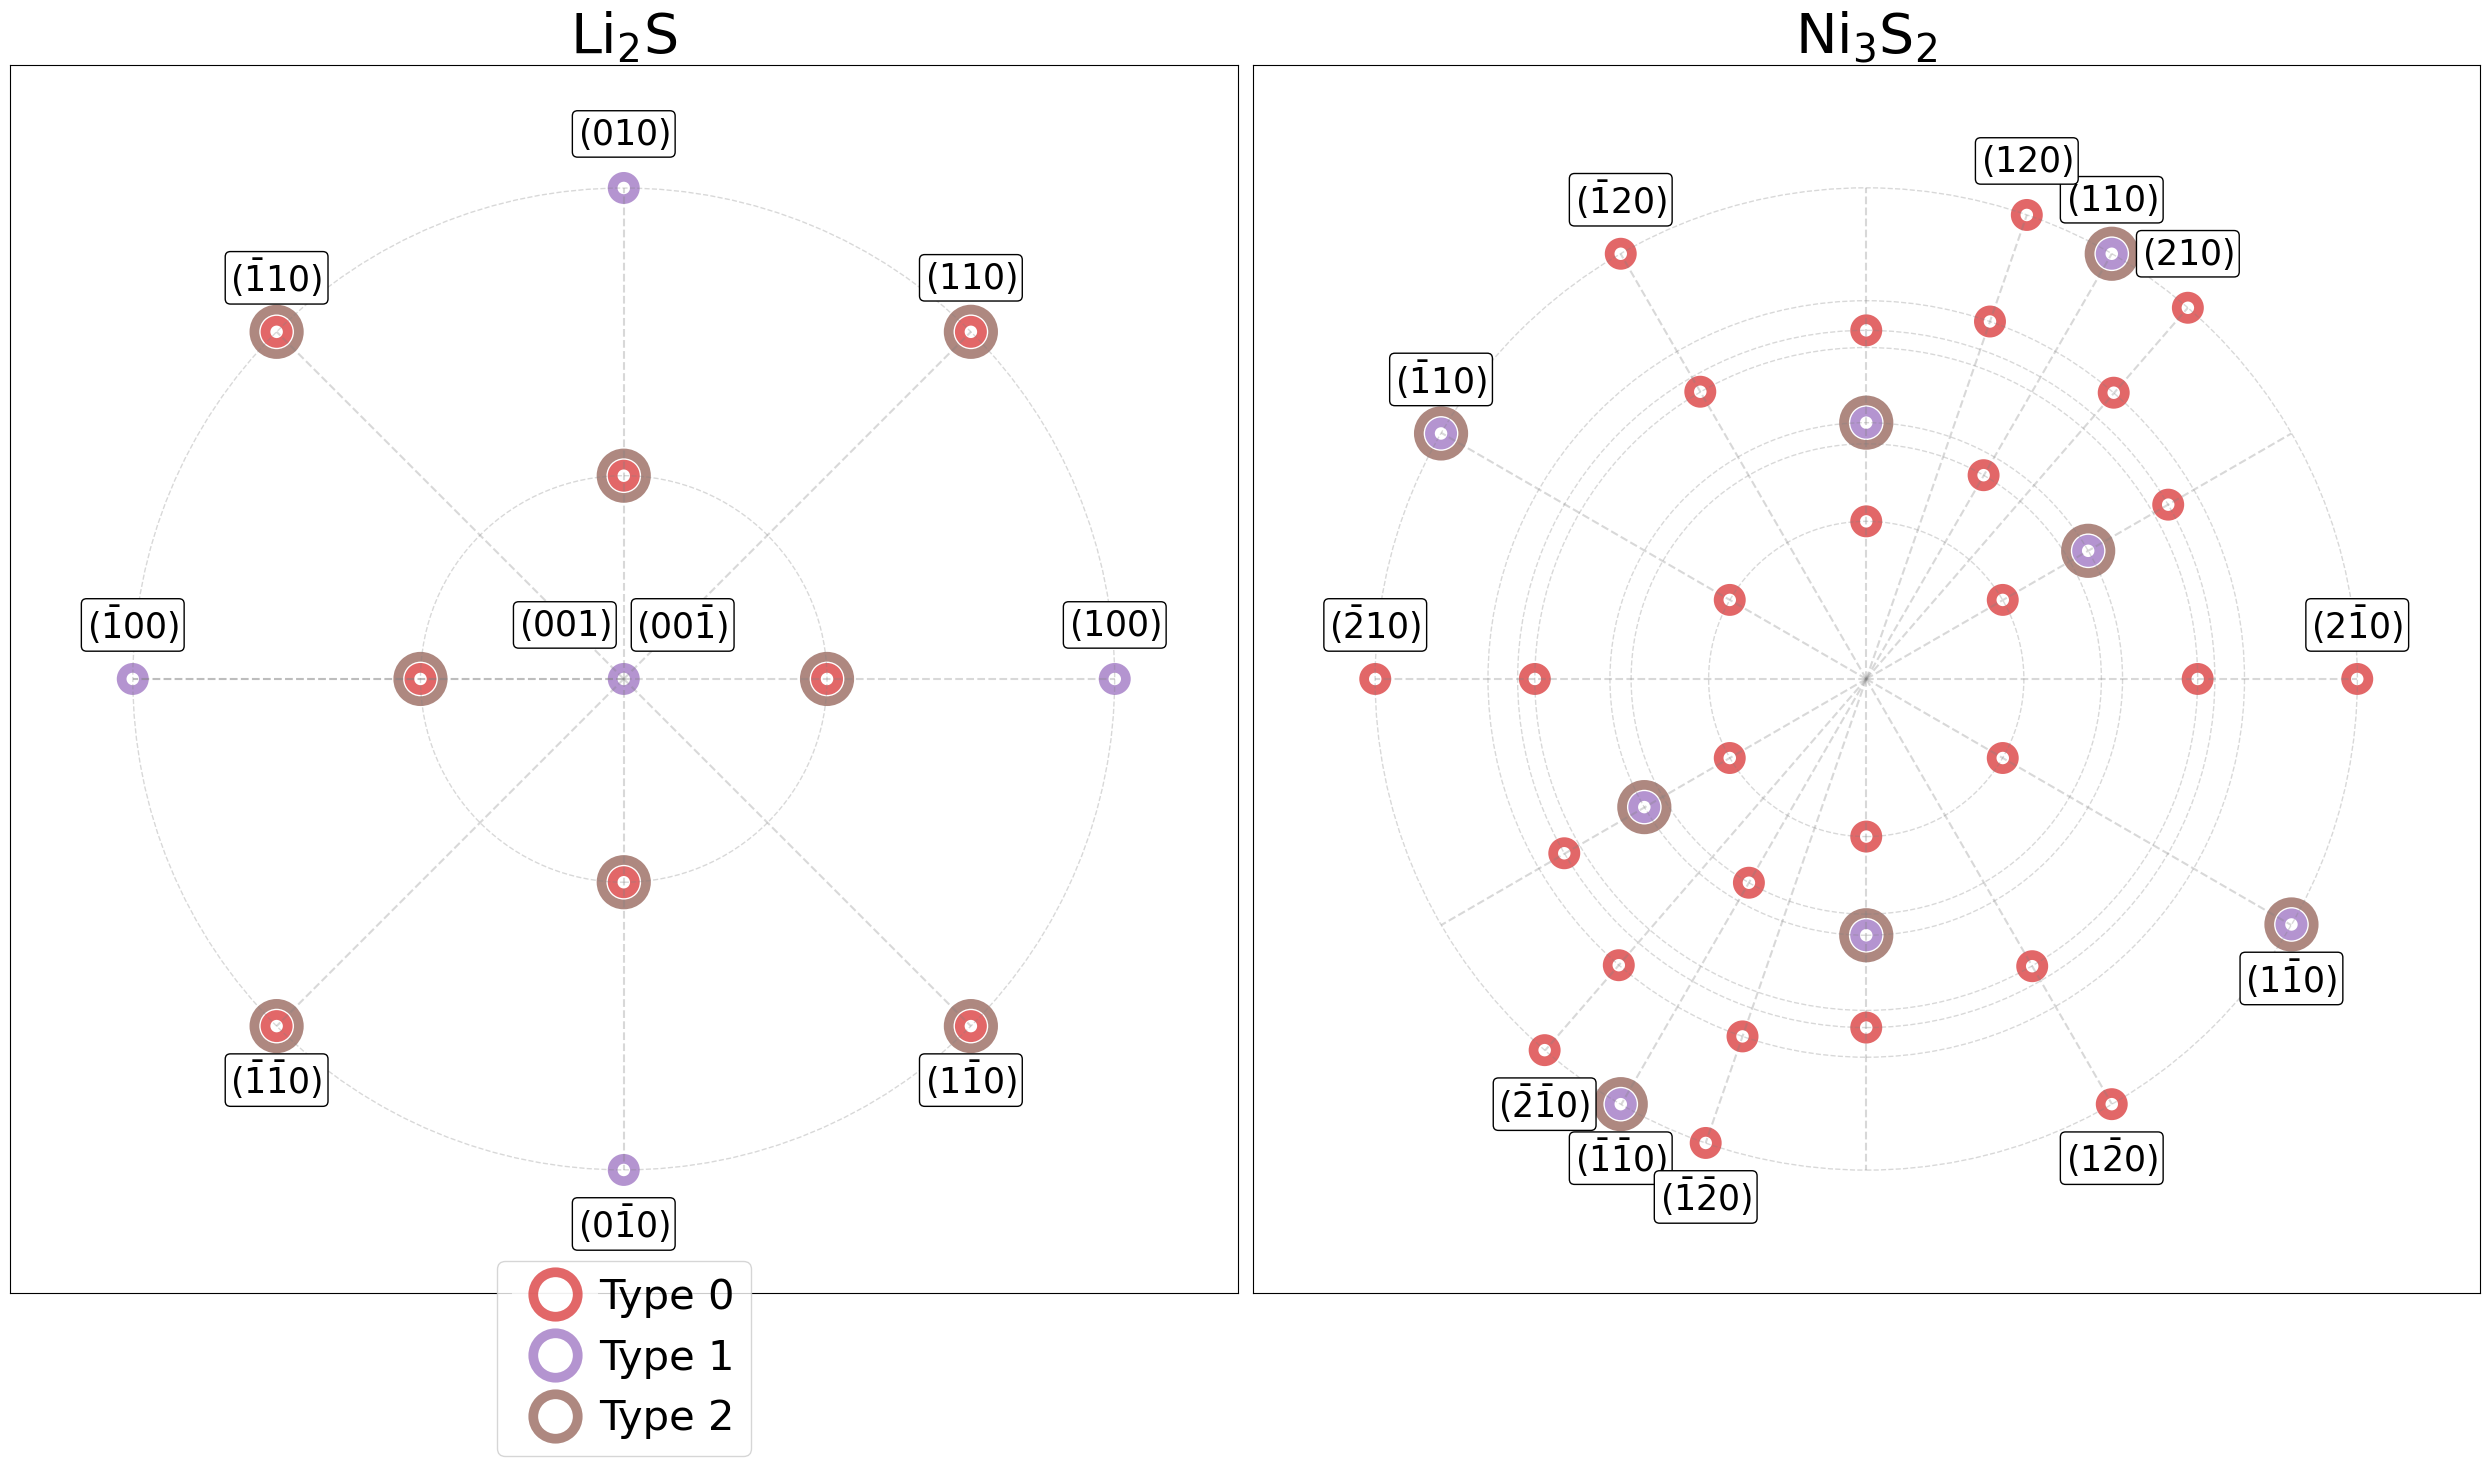

In [5]:
iw.ems.plot_matching_data(['Li$_2$S', 'Ni$_3$S$_2$'],'Ni3S2_Li2S_more.jpg', show_millers = True, show_legend = True)

# Define interface structural parameters 

For usage presentation, a large **termination_ftol** value is applied there.  
However, for some complex systems, a small enough **termination_ftol** (e.g. 0.01) is necessary to find stable interface structures.

In [6]:
#These are defualt settings
iw.parse_interface_structure_params(termination_ftol = 0.15, film_thickness = 15, \
                                    substrate_thickness = 15, double_interface= False,
                                   vacuum_over_film=5)



match 0: thicknesses (film, substrate) (2.0, 2.86) (7, 5) (14.03 14.32)
match 1: thicknesses (film, substrate) (2.84, 4.03) (5, 4) (14.18 16.12)
match 2: thicknesses (film, substrate) (2.0, 2.84) (7, 5) (14.03 14.18)
symmetry checking progress: 100%:  ▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋
match 0: number of unique terminations: 4
symmetry checking progress: 100%:  ▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋
match 1: number of unique terminations: 6
symmetry checking progress: 100%:  ▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋
match 2: number of unique terminations: 3


# Baysian Optimization by MLIP for Rigid Body Translation (RBT)

In [9]:
#define structure optimization conditions (optional). If not called, the non-optimized energy and structure will be used
iw.parse_optimization_params(set_relax_thicknesses = (4,4),
                             relax_in_layers = False,
                             fmax = 0.05,
                             steps = 200,
                             device = 'cpu',
                             discut = 0.8,
                             ckpt_path = '',
                             BO_coord_bin_size = 0.25,
                             BO_energy_bin_size = 0.05,
                             BO_rms_bin_size = 0.3,
                            do_gd=True)

match 0: fix/slab thicknesses (film, substrate) (10.03/14.03, 10.32/14.32)
match 1: fix/slab thicknesses (film, substrate) (10.18/14.18, 12.12/16.12)
match 2: fix/slab thicknesses (film, substrate) (10.03/14.03, 10.18/14.18)


**set_relax_thicknesses**: thickness for relaxing  
**relax_in_layers**: whether to set relaxing thickness in layers  
**fmax**: tolerance to stop structure optimization  
**steps**: maximum relaxing steps  
**device**: device to use for MLIP  
**ckpt_path**: path to store the check point, downloading if not set  
**discut**: those with atoyms closer than discut will have energy as 0 (ignore these structures)  
**do_gd**: whether to do gradient descend for RBT

In [10]:
iw.global_minimization(n_calls_density = 1, 
                       z_range = (0.5, 3),
                       calc = 'orb-models', 
                       strain_E_correction = True)

Initializing ORB calculator on device: cpu
Failed to load custom ORB model: file orb-v3-conservative-20-omat-20250404.ckpt not found
Using default ORB model


/opt/anaconda3/envs/3.12/lib/python3.12/site-packages/orb_models/utils.py:30: UserWarning: Setting global torch default dtype to torch.float32.
  warnings.warn(f"Setting global torch default dtype to {torch_dtype}.")


matches:   0%|          | 0/3 [00:00<?, ?it/s]

unique terminations:   0%|          | 0/4 [00:00<?, ?it/s]

registration optimizing:   0%|          | 0/22 [00:00<?, ?it/s]

...

num of selected low-energy its: 2


registration optimizing:   0%|          | 0/22 [00:00<?, ?it/s]

num of selected low-energy its: 1


registration optimizing:   0%|          | 0/22 [00:00<?, ?it/s]

num of selected low-energy its: 2
[np.float64(-0.11452362221944744), np.float64(-0.20489827352151627), np.float64(-0.7818474212796646)]
-----gradient descend------
dy -0.0038604736328125 x_n 0.000732421875 0.000579833984375 -0.017578125 g_n -0.00732421875 -0.00579833984375 0.17578125
dy -0.0043182373046875 x_n -0.0022126302859727344 -0.0024353384661447044 -0.05572356251355161 g_n 0.0128173828125 0.01312255859375 0.166015625
dy -0.00244140625 x_n -0.002571973586798301 0.002487664755165555 -0.07473282312722407 g_n 0.0030517578125 -0.04180908203125 0.16143798828125
dy -0.0094451904296875 x_n 0.003279410923546079 0.013334133603608796 -0.14337955360223983 g_n -0.01251220703125 -0.023193359375 0.14678955078125
dy -0.002349853515625 x_n 0.0034435079466861944 0.01552398008482344 -0.14587496005757744 g_n -0.00885009765625 -0.11810302734375 0.13458251953125
-----gradient descend------
dy -0.008575439453125 x_n 0.01519775390625 0.01507568359375 -0.00146484375 g_n -0.1519775390625 -0.1507568359375

**n_calls**: number of bayesian optimization for each RBT optimizatio  
**z_range**: range of z coordinates for RBT optimization  
**calc**: energy calculator (only for orb-models and sevenn)  
**strain_E_correction**: whether the binding energy or interface energy is corrected considering film elastic energy by strain

In [22]:
from pymatgen.transformations.site_transformations import TranslateSitesTransformation

In [23]:
it = iw.opt_results[(0,1)]['relaxed_best_interface']['structure']

In [24]:
import numpy as np

In [25]:
from numpy import inf, zeros, dot
from numpy.linalg import norm

In [9]:
iw.global_optimized_data

,$h_f$,$k_f$,$l_f$,$h_s$,$k_s$,$l_s$,$A$ (Å$^2$),$\epsilon$,$E_{bd}$ $(J/m^2)$,$E_{el}$ $(eV/atom)$,...,$w_{f2}$,$u_{s1}$,$v_{s1}$,$w_{s1}$,$u_{s2}$,$v_{s2}$,$w_{s2}$,$T$,$i_m$,$i_t$
1,-1,0,1,1,-1,2,22.870982,0.003387,-0.650997,-0.000196,...,0,-1/3,1/3,1/3,1,1,0,"(1_Li2S_Pmmm_3, 2_Ni_Pmmm_1)",0,1
0,-1,0,1,1,-1,2,22.870982,0.003387,-0.589133,-0.000196,...,0,-1/3,1/3,1/3,1,1,0,"(1_Li2S_Pmmm_3, 1_Ni_Pmmm_1)",0,0
3,-1,0,1,1,-1,2,22.870982,0.003387,-0.406871,-0.000196,...,0,-1/3,1/3,1/3,1,1,0,"(1_Li2S_Pmmm_3, 4_Ni_Pmmm_1)",0,3
2,-1,0,1,1,-1,2,22.870982,0.003387,-0.191697,-0.000196,...,0,-1/3,1/3,1/3,1,1,0,"(1_Li2S_Pmmm_3, 3_S_Pmmn_2)",0,2


# Get the interface with lowest predicted energy by MLIP for each match

In [19]:
iw.global_optimized_data.to_csv('all_data.csv')

In [20]:
import shutil
import os
try:
    shutil.rmtree('it_and_slab_structures')
except:
    pass
os.mkdir('it_and_slab_structures')

In [21]:
#Output lowest-it-energy interfaces for each lattice matching type
ids = iw.global_optimized_data.index.to_numpy()
i_s = iw.global_optimized_data['$i_m$'].to_numpy()
j_s = iw.global_optimized_data['$i_t$'].to_numpy()

match_ids = []
pairs = []
for i in range(len(i_s)):
    if i_s[i] not in match_ids:
        match_ids.append(i_s[i])
        pairs.append((i_s[i], j_s[i]))

for i in range(len(ids)):
    iw.opt_results[(i_s[i],j_s[i])]['relaxed_best_interface']['structure'].to_file(f'it_and_slab_structures/{ids[i]}_it_POSCAR')
    iw.opt_results[(i_s[i],j_s[i])]['slabs']['film']['structure'].to_file(f'it_and_slab_structures/{ids[i]}_film_POSCAR')
    iw.opt_results[(i_s[i],j_s[i])]['slabs']['substrate']['structure'].to_file(f'it_and_slab_structures/{ids[i]}_substrate_POSCAR')

In [22]:
lowest_it_each_match = {}

In [23]:
try:
    shutil.rmtree('lowest_it_each_match')
except:
    pass
os.mkdir('lowest_it_each_match')

In [24]:
types = []
it_Es = []
for i in pairs:
    lowest_it_each_match[i[0]] = {}
    lowest_it_each_match[i[0]]['A'] = iw.opt_results[i]['A']
    lowest_it_each_match[i[0]]['bd_E'] = iw.opt_results[i]['relaxed_min_bd_E']
    types.append(i[0])
    it_Es.append(lowest_it_each_match[i[0]]['bd_E'])
    iw.opt_results[i]['relaxed_best_interface']['structure'].to_file(f'lowest_it_each_match/{i[0]}_it_POSCAR')

In [25]:
import numpy as np

In [26]:
np.savetxt('bd_Es.dat',np.column_stack((types, it_Es)), fmt = '%i %.4f')